In [ ]:
from pathlib import Path
import pandas as pd
import gseapy as gp

# Root directory containing one folder per dataset.
datasets_root = Path('PATH/TO/NICO_OUT')
excel_files = sorted(datasets_root.glob('*/gene_correlation.xlsx'))

factors = ['Fa1', 'Fa2', 'Fa3']
all_factor_tables = {}
all_enrichment_tables = {}
significant_pathway_tables = []

for excel_path in excel_files:
    dataset_name = excel_path.parent.name
    correlation_df = pd.read_excel(excel_path, sheet_name=1)
    columns = correlation_df.columns.tolist()

    if 'Infl.mesenchymal' not in columns:
        print(f"[{dataset_name}] Skipped: 'Infl.mesenchymal' column not found")
        continue

    Inflmesenchymal_index = columns.index('Infl.mesenchymal')
    Inflmesenchymal_cols = columns[Inflmesenchymal_index:Inflmesenchymal_index + 4]
    if len(Inflmesenchymal_cols) < 4:
        print(f"[{dataset_name}] Skipped: fewer than 3 columns after Infl.mesenchymal")
        continue

    Inflmesenchymal = correlation_df[Inflmesenchymal_cols].copy()
    Inflmesenchymal.columns = ['Infl.mesenchymal'] + [f'Fa{i}' for i in range(1, 4)]

    Inflmesenchymal = Inflmesenchymal.dropna(subset=['Infl.mesenchymal']).copy()
    Inflmesenchymal.index = Inflmesenchymal['Infl.mesenchymal'].astype(str)
    Inflmesenchymal = Inflmesenchymal.drop(columns=['Infl.mesenchymal'], errors='ignore')
    if 'Infl.mesenchymal' in Inflmesenchymal.index:
        Inflmesenchymal = Inflmesenchymal.drop(index='Infl.mesenchymal')

    all_factor_tables[dataset_name] = {}
    all_enrichment_tables[dataset_name] = {}

    for factor in factors:
        factor_df_sorted = Inflmesenchymal[[factor]].dropna().sort_values(by=factor, ascending=False)
        all_factor_tables[dataset_name][factor] = factor_df_sorted

        top_genes = factor_df_sorted.index.tolist()[:100]
        filtered_genes = [g for g in top_genes if not str(g).startswith('RP')]

        if len(filtered_genes) < 5:
            print(f"[{dataset_name} - {factor}] Skipped enrichment: <5 usable genes")
            continue

        enr = gp.enrichr(
            gene_list=filtered_genes,
            gene_sets='Reactome_Pathways_2024',
            organism='Human',
            outdir=None,
            cutoff=0.05,
        )

        enr_res = enr.results.copy()
        if enr_res.empty:
            print(f"[{dataset_name} - {factor}] No enrichment results")
            continue

        sig = enr_res[enr_res['Adjusted P-value'] < 0.05].copy()
        if sig.empty:
            print(f"[{dataset_name} - {factor}] No significant pathways (Adj P < 0.05)")
            continue

        keep_cols = [
            c for c in ['Term', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']
            if c in sig.columns
        ]
        sig = sig[keep_cols].sort_values('Adjusted P-value', ascending=True)
        sig.insert(0, 'Factor', factor)
        sig.insert(0, 'Dataset', dataset_name)

        all_enrichment_tables[dataset_name][factor] = sig
        significant_pathway_tables.append(sig)

if significant_pathway_tables:
    significant_pathways_df = pd.concat(significant_pathway_tables, ignore_index=True)
else:
    significant_pathways_df = pd.DataFrame(
        columns=['Dataset', 'Factor', 'Term', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']
    )

print(f"Datasets detected: {len(excel_files)}")
print(f"Datasets processed: {len(all_factor_tables)}")
print(f"Total significant pathways: {len(significant_pathways_df)}")
significant_pathways_df.head(20)

Datasets detected: 10
Datasets processed: 10
Total significant pathways: 1605


,Dataset,Factor,Term,P-value,Adjusted P-value,Odds Ratio,Combined Score
0,C1,Fa1,Immune System,9.191686e-17,7.059214e-14,8.426679,311.160587
1,C1,Fa1,Innate Immune System,8.390336e-14,3.221889e-11,8.898690,267.931645
2,C1,Fa1,Neutrophil Degranulation,1.263597e-10,3.234809e-08,11.063431,252.156476
3,C1,Fa1,Interferon Alpha Beta Signaling,3.624732e-10,6.260853e-08,35.460714,770.847509
4,C1,Fa1,Endosomal Vacuolar Pathway,4.076076e-10,6.260853e-08,212.377399,4591.751439
5,C1,Fa1,Interferon Signaling,4.721399e-09,6.043391e-07,13.178682,252.650637
6,C1,Fa1,Cytokine Signaling in Immune System,1.220493e-08,1.339055e-06,7.206015,131.303868
7,C1,Fa1,Regulation of IGF Transport and Uptake by Insu...,1.492781e-08,1.433069e-06,21.349138,384.712324
8,C1,Fa1,"Platelet Activation, Signaling and Aggregation",3.293111e-08,2.810121e-06,12.593446,216.970567
9,C1,Fa1,Signaling by Receptor Tyrosine Kinases,5.317954e-08,3.749416e-06,8.175292,136.932814


In [ ]:
from pathlib import Path

output_csv = Path('./factors_pathways') / 'Inflmesenchymal_significant_pathways_df.csv'
significant_pathways_df.to_csv(output_csv, index=False)
print(f"Saved CSV: {output_csv}")
print(f"Rows: {len(significant_pathways_df)}")

In [ ]:
from pathlib import Path
import pandas as pd

base_dir = Path('./factors_pathways')
input_csv = base_dir / 'Inflmesenchymal_significant_pathways_df.csv'
output_csv = base_dir / 'Inflmesenchymal_significant_pathways_senescence_inflammation.csv'

significant_pathways_df = pd.read_csv(input_csv)

# Match common senescence and inflammation pathway terms (case-insensitive).
keywords = [
    'inflamm', 'cytokine','ifn'
    'interleukin', 'il-?\\d+', 'tnf', 'nf-?kb', 'jak-?stat', 'interferon'
 ]
pattern = '|'.join(keywords)

selected_pathways_df = significant_pathways_df[
    significant_pathways_df['Term'].str.contains(pattern, case=False, na=False, regex=True)
].copy()

selected_pathways_df.to_csv(output_csv, index=False)

print(f'Total pathways: {len(significant_pathways_df)}')
print(f'Selected senescence/inflammation pathways: {len(selected_pathways_df)}')
print(f'Saved filtered CSV: {output_csv}')
selected_pathways_df.head(50)

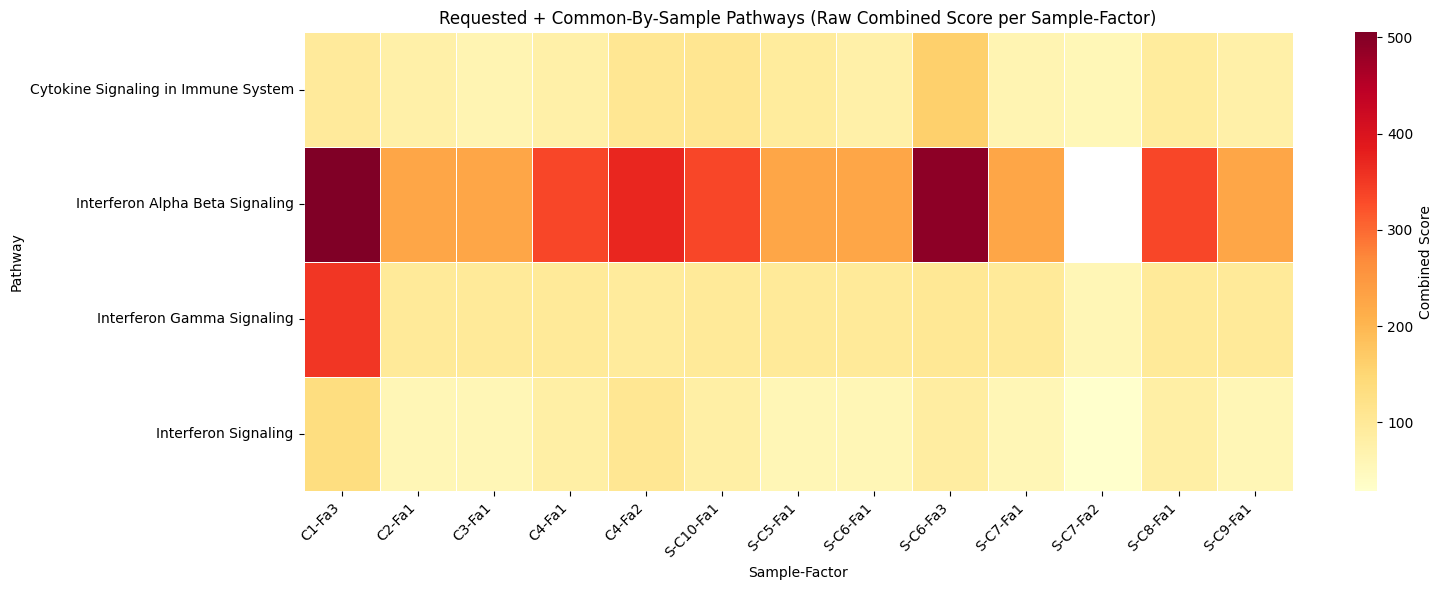

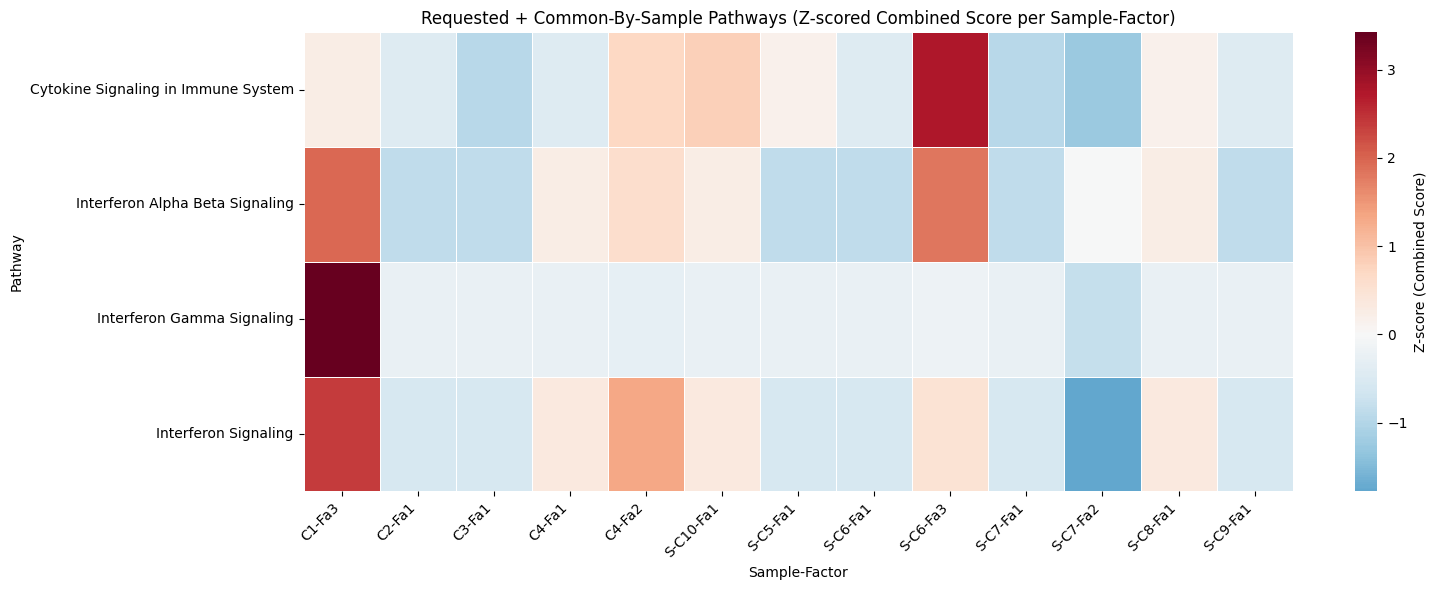

Sample-factor columns: 13
Datasets: 10
Requested pathways found: 0
Common pathways across samples found: 4
Combined pathways total: 4
Saved raw PDF: /Users/cheung/Documents/Nature_cancer/revision/spatial/2025_run/cytopenia/factors_pathways/Inflmesenchymal_concatenated_selected_and_common_pathways_raw_heatmap_sample_factor.pdf
Saved z-score PDF: /Users/cheung/Documents/Nature_cancer/revision/spatial/2025_run/cytopenia/factors_pathways/Inflmesenchymal_concatenated_selected_and_common_pathways_zscore_heatmap_sample_factor.pdf


Sample_Fa,C1-Fa3,C2-Fa1,C3-Fa1,C4-Fa1,C4-Fa2,S-C10-Fa1,S-C5-Fa1,S-C6-Fa1,S-C6-Fa3,S-C7-Fa1,S-C7-Fa2,S-C8-Fa1,S-C9-Fa1
Term,,,,,,,,,,,,,
Cytokine Signaling in Immune System,95.966753,77.940118,64.494538,77.940118,107.727980,110.221366,93.142519,77.940118,160.718812,64.494538,56.398303,93.142519,77.940118
Interferon Alpha Beta Signaling,505.301337,226.199967,226.199967,334.165308,371.397798,334.165308,226.199967,226.199967,492.161102,226.199967,NaN,334.165308,226.199967
Interferon Gamma Signaling,353.124919,98.461712,98.461712,98.461712,94.664611,98.461712,98.461712,98.461712,103.334679,98.461712,59.085442,98.461712,98.461712
Interferon Signaling,133.305373,59.065853,59.065853,81.557683,106.766105,81.557683,59.065853,59.065853,86.198951,59.065853,28.427633,81.557683,59.065853


In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

base_dir = Path('./factors_pathways')
input_csv = base_dir / 'Inflmesenchymal_significant_pathways_senescence_inflammation_selected.csv'
output_pdf_z = base_dir / 'Inflmesenchymal_concatenated_selected_and_common_pathways_zscore_heatmap_sample_factor.pdf'
output_pdf_raw = base_dir / 'Inflmesenchymal_concatenated_selected_and_common_pathways_raw_heatmap_sample_factor.pdf'

heatmap_df = pd.read_csv(input_csv)

requested_pathways = [

]

selected_df = heatmap_df[heatmap_df['Term'].isin(requested_pathways)].copy()
missing_pathways = [
    pathway for pathway in requested_pathways
    if pathway not in set(selected_df['Term'])
]
if missing_pathways:
    raise ValueError(f'Requested pathways not found: {missing_pathways}')

if {'Dataset', 'Factor'}.issubset(heatmap_df.columns):
    heatmap_df['Sample_Fa'] = heatmap_df['Dataset'].astype(str) + '-' + heatmap_df['Factor'].astype(str)

    dataset_order = sorted(heatmap_df['Dataset'].astype(str).unique())
    dataset_count = len(dataset_order)
    factor_values = heatmap_df['Factor'].astype(str).unique().tolist()

    def factor_sort_key(f):
        m = re.search(r'(\d+)', f)
        return (int(m.group(1)), f) if m else (10**9, f)

    factor_order = sorted(factor_values, key=factor_sort_key)
    sample_factor_order = [
        f'{dataset}-{factor}'
        for dataset in dataset_order
        for factor in factor_order
        if ((heatmap_df['Dataset'].astype(str) == dataset) & (heatmap_df['Factor'].astype(str) == factor)).any()
    ]

    # Keep pathways common across samples (datasets), then visualize by sample-factor columns.
    common_pathways = (
        heatmap_df.groupby('Term')['Dataset'].nunique()
        .loc[lambda s: s.eq(dataset_count)]
        .index
        .tolist()
    )
else:
    heatmap_df['Sample_Fa'] = heatmap_df['Dataset'].astype(str)
    sample_factor_order = sorted(heatmap_df['Sample_Fa'].unique())
    dataset_count = len(sample_factor_order)
    common_pathways = (
        heatmap_df.groupby('Term')['Sample_Fa'].nunique()
        .loc[lambda s: s.eq(dataset_count)]
        .index
        .tolist()
    )

sample_factor_count = len(sample_factor_order)

combined_pathways = list(dict.fromkeys(requested_pathways + common_pathways))
combined_df = heatmap_df[heatmap_df['Term'].isin(combined_pathways)].copy()

score_matrix = (
    combined_df.groupby(['Term', 'Sample_Fa'])['Combined Score']
    .max()
    .unstack('Sample_Fa')
    .reindex(index=combined_pathways, columns=sample_factor_order)
)

row_mean = score_matrix.mean(axis=1)
row_std = score_matrix.std(axis=1, ddof=0).replace(0, np.nan)
zscore_matrix = score_matrix.sub(row_mean, axis=0).div(row_std, axis=0).fillna(0)

fig_raw, ax_raw = plt.subplots(figsize=(max(8, score_matrix.shape[1] * 1.2), max(6, score_matrix.shape[0] * 0.5)))
sns.heatmap(
    score_matrix,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Combined Score'},
    ax=ax_raw,
)
ax_raw.set_title('Requested + Common-By-Sample Pathways (Raw Combined Score per Sample-Factor)')
ax_raw.set_xlabel('Sample-Factor')
ax_raw.set_ylabel('Pathway')
ax_raw.set_xticklabels(ax_raw.get_xticklabels(), rotation=45, ha='right')
ax_raw.set_yticklabels(ax_raw.get_yticklabels(), rotation=0)
fig_raw.tight_layout()
plt.show()

fig_z, ax_z = plt.subplots(figsize=(max(8, zscore_matrix.shape[1] * 1.2), max(6, zscore_matrix.shape[0] * 0.5)))
sns.heatmap(
    zscore_matrix,
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Z-score (Combined Score)'},
    ax=ax_z,
)
ax_z.set_title('Requested + Common-By-Sample Pathways (Z-scored Combined Score per Sample-Factor)')
ax_z.set_xlabel('Sample-Factor')
ax_z.set_ylabel('Pathway')
ax_z.set_xticklabels(ax_z.get_xticklabels(), rotation=45, ha='right')
ax_z.set_yticklabels(ax_z.get_yticklabels(), rotation=0)
fig_z.tight_layout()
plt.show()

with PdfPages(output_pdf_raw) as pdf:
    pdf.savefig(fig_raw)
with PdfPages(output_pdf_z) as pdf:
    pdf.savefig(fig_z)

plt.close(fig_raw)
plt.close(fig_z)

print(f'Sample-factor columns: {sample_factor_count}')
print(f'Datasets: {dataset_count}')
print(f'Requested pathways found: {selected_df["Term"].nunique()}')
print(f'Common pathways across samples found: {len(common_pathways)}')
print(f'Combined pathways total: {len(combined_pathways)}')
print(f'Saved raw PDF: {output_pdf_raw}')
print(f'Saved z-score PDF: {output_pdf_z}')
score_matrix.head()